In [1]:
from scipy.spatial import distance
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(29)

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [4]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1, random_state=29).reset_index(drop=True)

In [5]:
df['label'].unique()

array(['odroid2', 'rpi-4a', 'odroid1', 'odroid4', 'rpi-8c', 'odroid3',
       'rpi-8a', 'rpi-8d', 'rpi-8b'], dtype=object)

In [6]:
nodes = list(df['label'].unique())
node_traces = {}

In [7]:
for node in nodes:
    single_node_df = df.loc[df['label'] == node]
    single_node_df = single_node_df.drop(columns='label')
    single_node_df.reset_index(inplace=True, drop=True)
    node_traces[node] = single_node_df

In [8]:
node_traces['odroid1']

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,165.0,167.0,167.0,168.0,169.0,166.0,168.0
1,163.0,169.0,166.0,168.0,166.0,167.0,167.0
2,166.0,169.0,166.0,168.0,169.0,168.0,168.0
3,165.0,168.0,166.0,167.0,169.0,166.0,167.0
4,163.0,167.0,167.0,166.0,167.0,166.0,168.0
...,...,...,...,...,...,...,...
1995,166.0,170.0,168.0,166.0,169.0,165.0,167.0
1996,166.0,166.0,169.0,166.0,167.0,167.0,167.0
1997,165.0,170.0,165.0,167.0,169.0,169.0,166.0
1998,166.0,169.0,168.0,167.0,168.0,167.0,169.0


In [ ]:
hamming_matrix = pd.DataFrame(columns=nodes)

for node in nodes:
    compare_nodes = nodes.copy()
    compare_nodes.remove(node)
    hamming_row = {}

    for compare_node in compare_nodes:
        # print(node, compare_node)

        hamming_list = []
        for i in range(2000):
            hamming_list.append(distance.hamming(list(node_traces[node].iloc[i]), list(node_traces[compare_node].iloc[i])))
        
        print(sum(hamming_list) / 2000)
        hamming_row[compare_node] = sum(hamming_list) / 2000
    
    hamming_matrix.loc[node] = hamming_row

0.9999285714285715
0.9384285714285787
0.977000000000003
0.9998571428571429
0.926428571428581
1.0
1.0
1.0
0.9999285714285715
0.9998571428571429
0.9999285714285715
0.9935714285714293
1.0
0.9978571428571432
0.9920714285714298
0.9982857142857146
0.9384285714285787
0.9998571428571429
0.9992857142857144
0.9998571428571429
0.9150000000000088
0.9997857142857144
0.9997142857142858
1.0
0.977000000000003
0.9999285714285715
0.9992857142857144
0.9999285714285715
0.9457857142857208
1.0
0.9999285714285715
1.0
0.9998571428571429
0.9935714285714293
0.9998571428571429
0.9999285714285715
1.0
0.9976428571428575
0.9943571428571437
0.998357142857143
0.926428571428581
1.0
0.9150000000000088
0.9457857142857208
1.0
1.0
1.0
1.0
1.0
0.9978571428571432
0.9997857142857144
1.0
0.9976428571428575
1.0
0.9981428571428574
0.9897142857142872
1.0
0.9920714285714298
0.9997142857142858
0.9999285714285715
0.9943571428571437
1.0
0.9981428571428574
0.998857142857143
1.0
0.9982857142857146
1.0
1.0
0.998357142857143
1.0
0.98971

In [80]:
hamming_matrix

,odroid2,rpi-4a,odroid1,odroid4,rpi-8c,odroid3,rpi-8a,rpi-8d,rpi-8b
odroid2,NaN,0.999929,0.938429,0.977000,0.999857,0.926429,1.000000,1.000000,1.000000
rpi-4a,0.999929,NaN,0.999857,0.999929,0.993571,1.000000,0.997857,0.992071,0.998286
odroid1,0.938429,0.999857,NaN,0.999286,0.999857,0.915000,0.999786,0.999714,1.000000
odroid4,0.977000,0.999929,0.999286,NaN,0.999929,0.945786,1.000000,0.999929,1.000000
rpi-8c,0.999857,0.993571,0.999857,0.999929,NaN,1.000000,0.997643,0.994357,0.998357
odroid3,0.926429,1.000000,0.915000,0.945786,1.000000,NaN,1.000000,1.000000,1.000000
rpi-8a,1.000000,0.997857,0.999786,1.000000,0.997643,1.000000,NaN,0.998143,0.989714
rpi-8d,1.000000,0.992071,0.999714,0.999929,0.994357,1.000000,0.998143,NaN,0.998857
rpi-8b,1.000000,0.998286,1.000000,1.000000,0.998357,1.000000,0.989714,0.998857,NaN


<Axes: >

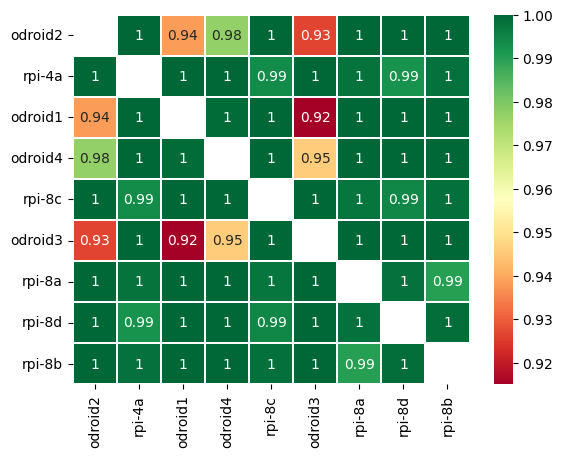

In [89]:
sns.heatmap(hamming_matrix, cmap ='RdYlGn', linewidths = 0.30, annot = True) 

In [72]:
jaccard_matrix = pd.DataFrame(columns=nodes)

for node in nodes:
    compare_nodes = nodes.copy()
    compare_nodes.remove(node)
    jaccard_row = {}

    for compare_node in compare_nodes:
        # print(node, compare_node)

        jaccard_list = []
        for i in range(2000):
            jaccard_list.append(distance.dice(list(node_traces[node].iloc[i]), list(node_traces[compare_node].iloc[i])))
        
        print(sum(jaccard_list) / 2000)
        jaccard_row[compare_node] = sum(jaccard_list) / 2000
    
    jaccard_matrix.loc[node] = jaccard_row

-178.26297608848617
-163.39798426895604
-167.3264563696708
-164.70955795289245
-165.27980085486232
-188.2876525001923
-177.91264209479604
-189.64658303911932
-178.2629760884862
-180.19657973283034
-187.39920945317024
-234.6799540291459
-184.43027313944052
-207.33565330048225
-313.62581552949104
-212.17253940609834
-163.39798426895604
-180.19657973283034
-168.59702614476723
-164.06305856119832
-166.59110172583394
-189.47980481470856
-173.71309452005303
-191.12834700186215
-167.3264563696708
-187.3992094531703
-168.59702614476723
-169.7508732225154
-169.92335980786197
-193.70200943182925
-184.6350192447016
-195.34886358671014
-164.70955795289248
-234.6799540291459
-164.06305856119832
-169.75087322251542
-167.1846199795402
-191.68994037857038
-206.97493461993875
-196.61328573867195
-165.27980085486232
-184.43027313944052
-166.59110172583394
-169.92335980786197
-167.1846199795402
-190.96685802837342
-181.56445733940285
-192.57094709889662
-188.28765250019225
-207.3356533004823
-189.4798048

In [73]:
jaccard_matrix

,odroid2,rpi-4a,odroid1,odroid4,rpi-8c,odroid3,rpi-8a,rpi-8d,rpi-8b
odroid2,NaN,-178.262976,-163.397984,-167.326456,-164.709558,-165.279801,-188.287653,-177.912642,-189.646583
rpi-4a,-178.262976,NaN,-180.196580,-187.399209,-234.679954,-184.430273,-207.335653,-313.625816,-212.172539
odroid1,-163.397984,-180.196580,NaN,-168.597026,-164.063059,-166.591102,-189.479805,-173.713095,-191.128347
odroid4,-167.326456,-187.399209,-168.597026,NaN,-169.750873,-169.923360,-193.702009,-184.635019,-195.348864
rpi-8c,-164.709558,-234.679954,-164.063059,-169.750873,NaN,-167.184620,-191.689940,-206.974935,-196.613286
odroid3,-165.279801,-184.430273,-166.591102,-169.923360,-167.184620,NaN,-190.966858,-181.564457,-192.570947
rpi-8a,-188.287653,-207.335653,-189.479805,-193.702009,-191.689940,-190.966858,NaN,-207.272707,-223.249307
rpi-8d,-177.912642,-313.625816,-173.713095,-184.635019,-206.974935,-181.564457,-207.272707,NaN,-206.415201
rpi-8b,-189.646583,-212.172539,-191.128347,-195.348864,-196.613286,-192.570947,-223.249307,-206.415201,NaN


<Axes: >

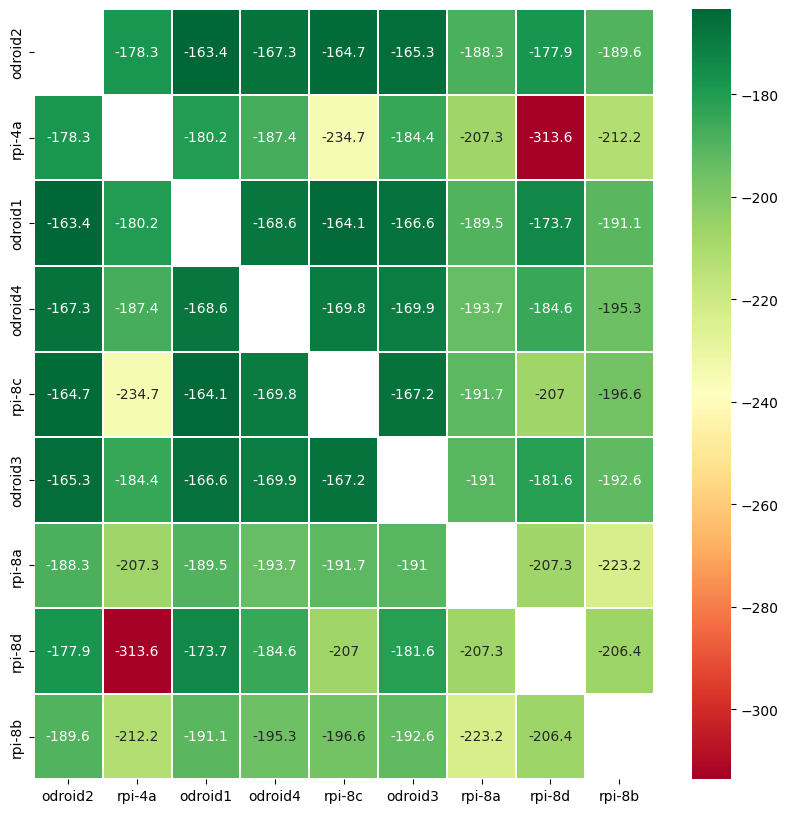

In [74]:
plt.figure(figsize=(10, 10))
sns.heatmap(jaccard_matrix, cmap ='RdYlGn', linewidths = 0.30, annot = True, fmt='.4g') 